ej1

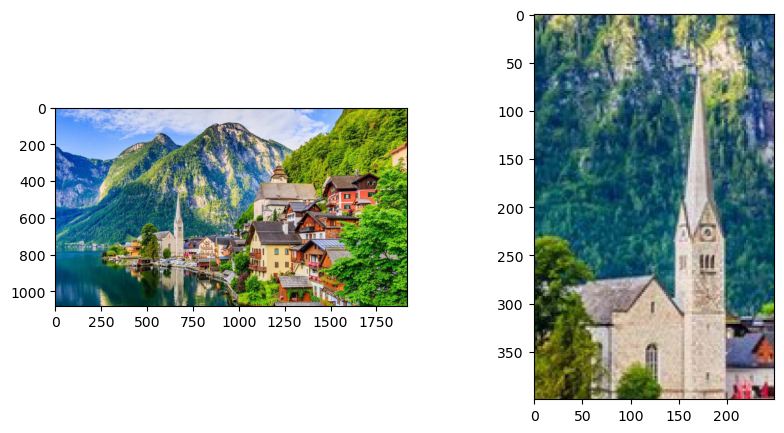

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("imagenP.jpg")
recortado = imagen[400:800, 500:750]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(recortado, cv2.COLOR_BGR2RGB))
plt.show()
cv2.imwrite("imgP.jpg", recortado)

ej2

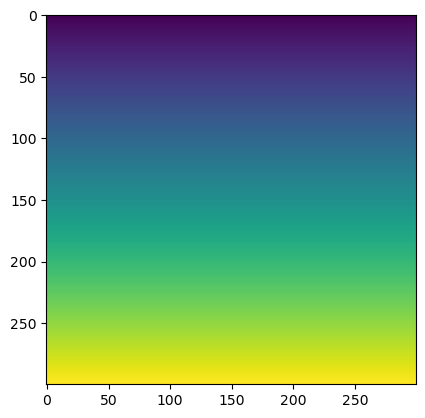

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

degradado = np.tile(np.linspace(0,1,300).reshape(300,1), (1,300))
plt.imshow(degradado)
plt.show()

ej3

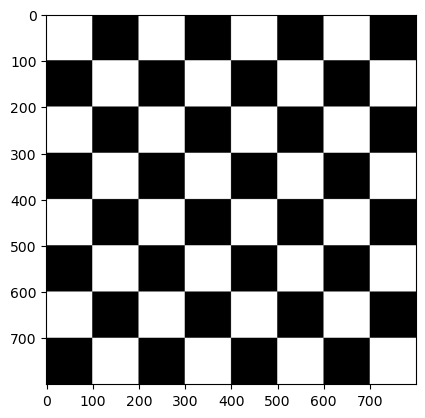

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

tam = 800
bloque = 100
tablero = np.zeros((tam, tam, 3), dtype=np.uint8)
for i in range(0, tam, bloque):
    for j in range(0, tam, bloque):
        if (i//bloque + j//bloque) % 2 == 0:
            tablero[i:i+bloque, j:j+bloque] = [255,255,255]
        else:
            tablero[i:i+bloque, j:j+bloque] = [0,0,0]
plt.imshow(tablero)
plt.show()


ej4

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def falso_color(img_gray):
    escala_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)
    escala_img = escala_img.astype(np.uint8)
    img_falso_color = cv2.applyColorMap(escala_img, cv2.COLORMAP_JET)
    return img_falso_color

def posterizar(imagen, niveles):
    factor_escala = 255 / niveles
    img_pos = np.round(imagen / factor_escala) * factor_escala
    return img_pos.astype(np.uint8)

def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)

ej5

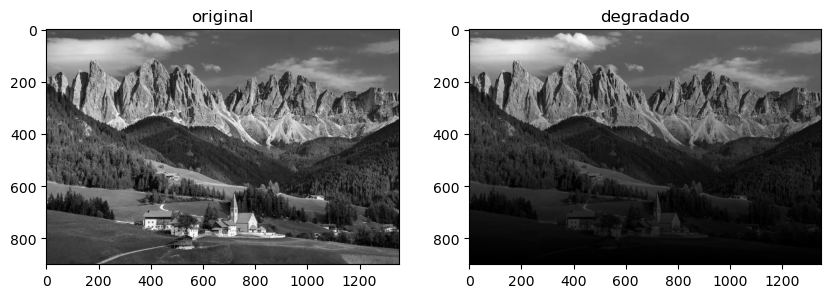

In [107]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("imagen1.jpg")
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
alto, ancho = img_gray.shape
degradado = np.linspace(1, 0, alto).reshape(alto, 1)
img_final = img_gray * degradado
img_final = img_final.astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original")
plt.imshow(img_gray, cmap='gray')
plt.subplot(1,2,2)
plt.title("degradado")
plt.imshow(img_final, cmap='gray')
plt.show()

ej6  

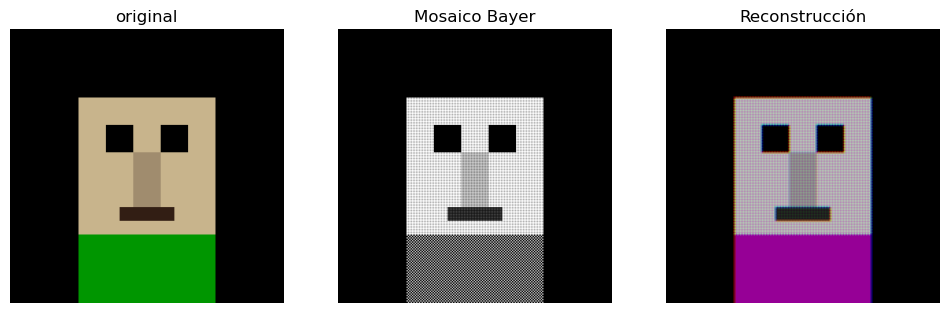

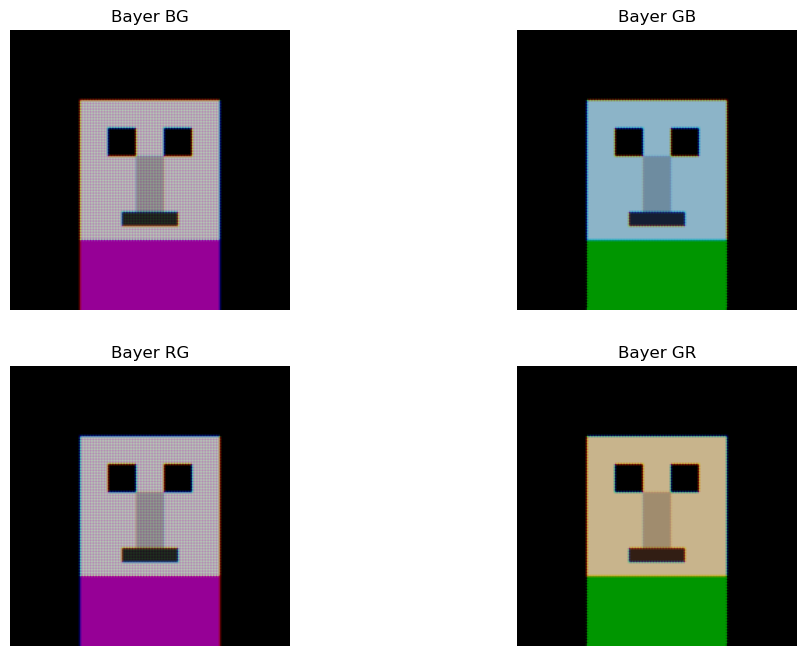

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb = np.zeros((200,200,3), dtype=np.uint8)
img_rgb[50:150,50:150] = [200,180,140]
img_rgb[70:90,70:90] = [0,0,0]
img_rgb[70:90,110:130] = [0,0,0]
img_rgb[90:130,90:110] = [160,140,110]
img_rgb[130:140,80:120] = [50,30,20]
img_rgb[150:200,50:150] = [0,150,0]

h, w, _ = img_rgb.shape
bayer = np.zeros((h, w), dtype=np.uint8)

bayer[0::2,0::2] = img_rgb[0::2,0::2,1]  
bayer[0::2,1::2] = img_rgb[0::2,1::2,2]  
bayer[1::2,0::2] = img_rgb[1::2,0::2,0] 
bayer[1::2,1::2] = img_rgb[1::2,1::2,1]  

recon_bg = cv2.cvtColor(bayer, cv2.COLOR_BAYER_BG2RGB)
recon_gb = cv2.cvtColor(bayer, cv2.COLOR_BAYER_GB2RGB)
recon_rg = cv2.cvtColor(bayer, cv2.COLOR_BAYER_RG2RGB)
recon_gr = cv2.cvtColor(bayer, cv2.COLOR_BAYER_GR2RGB)

plt.figure(figsize=(12,6))
plt.subplot(131); plt.imshow(img_rgb); plt.title("original"); plt.axis("off")
plt.subplot(132); plt.imshow(bayer, cmap="gray"); plt.title("Mosaico Bayer"); plt.axis("off")
plt.subplot(133); plt.imshow(recon_bg); plt.title("Reconstrucción"); plt.axis("off")
plt.show()

plt.figure(figsize=(12,8))
plt.subplot(221); plt.imshow(recon_bg); plt.title("Bayer BG"); plt.axis("off")
plt.subplot(222); plt.imshow(recon_gb); plt.title("Bayer GB"); plt.axis("off")
plt.subplot(223); plt.imshow(recon_rg); plt.title("Bayer RG"); plt.axis("off")
plt.subplot(224); plt.imshow(recon_gr); plt.title("Bayer GR"); plt.axis("off")
plt.show()

cv2.imwrite("img_rgb.jpg", img_rgb)
cv2.imwrite("bayer.jpg", bayer) 
cv2.imwrite("recon_bg.jpg", recon_bg)
cv2.imwrite("recon_gb.jpg", recon_gb)
cv2.imwrite("recon_rg.jpg", recon_rg)
cv2.imwrite("recon_gr.jpg", recon_gr)

